# Proyek Akhir: Multivariate Multi-Horizon Bitcoin Time Series Forecasting
**Nama:** Awanda Rosi Firdaus

Notebook ini membangun model Seq2Seq LSTM untuk memprediksi harga penutupan
Bitcoin 24 jam ke depan menggunakan data historis per jam.

## Section 1: Imports & Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from sklearn.preprocessing import MinMaxScaler
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import acf, pacf
import warnings
warnings.filterwarnings('ignore')

print(f"TensorFlow version: {tf.__version__}")
print(f"GPU available: {tf.config.list_physical_devices('GPU')}")

# Set random seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

TensorFlow version: 2.20.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## Section 2: Load Data

In [2]:
csv_url = 'https://drive.google.com/uc?export=download&id=1hpsqSpfjdqIZWqwd259klQSeaNSe5Trr'
df = pd.read_csv(csv_url)

print("Shape:", df.shape)
print("\nKolom:", df.columns.tolist())
print("\nInfo:")
print(df.info())
print("\nHead:")
df.head()

Shape: (53150, 7)

Kolom: ['Date', 'Close', 'Volume USDT', 'RSI', 'MACD_Hist', 'ATR', 'KAMAO']

Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53150 entries, 0 to 53149
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Date         53150 non-null  object 
 1   Close        53150 non-null  float64
 2   Volume USDT  53150 non-null  float64
 3   RSI          53150 non-null  float64
 4   MACD_Hist    53150 non-null  float64
 5   ATR          53150 non-null  float64
 6   KAMAO        53150 non-null  float64
dtypes: float64(6), object(1)
memory usage: 2.8+ MB
None

Head:


,Date,Close,Volume USDT,RSI,MACD_Hist,ATR,KAMAO
0,2017-09-21 09:00:00.000,3860.00,74434.891166,49.192454,-48.279697,88.054720,2.495591
1,2017-09-21 10:00:00.000,3871.48,44687.318944,49.233202,-47.780476,87.996283,2.616710
2,2017-09-21 11:00:00.000,3864.95,80546.171672,49.210685,-47.308061,87.897128,2.532239
3,2017-09-21 12:00:00.000,3858.08,90331.531390,49.186948,-46.863233,87.720856,2.447245
4,2017-09-21 13:00:00.000,3856.67,103405.818040,49.182064,-46.425379,87.578086,2.424654


In [3]:
print("\nStatistik Deskriptif:")
df.describe()


Statistik Deskriptif:


,Close,Volume USDT,RSI,MACD_Hist,ATR,KAMAO
count,53150.000000,5.315000e+04,53150.000000,53150.000000,53150.000000,53150.000000
mean,20595.357333,6.919215e+07,50.403605,0.528272,221.733334,0.229762
std,15822.296994,1.059041e+08,3.210682,353.293188,208.401440,5.168655
min,3172.050000,0.000000e+00,35.178834,-1885.690630,17.436266,-31.767152
25%,7976.915000,1.012558e+07,48.294197,-115.601600,72.702488,-2.717470
50%,13878.095000,2.766119e+07,50.038483,10.154419,128.787616,-0.032747
75%,29646.720000,8.944278e+07,52.406274,122.367509,325.616826,3.162442
max,68633.690000,3.005634e+09,64.657108,1430.405758,1004.531407,39.740297


## Section 3: Data Preprocessing Awal

In [4]:
# Tampilkan kolom yang tersedia
print("Kolom dataset:", df.columns.tolist())
print("\nSample data:")
print(df.head(3))

# Cek apakah ada kolom date/timestamp dan konversi
date_cols = [c for c in df.columns if any(d in c.lower() for d in ['date', 'time', 'unix', 'timestamp'])]
print(f"\nKolom tanggal yang ditemukan: {date_cols}")

# Jika ada kolom date, set sebagai index
if date_cols:
    date_col = date_cols[0]
    try:
        df[date_col] = pd.to_datetime(df[date_col], format='mixed')
    except:
        df[date_col] = pd.to_datetime(df[date_col]) # Fallback for older pandas
    df = df.sort_values(date_col).reset_index(drop=True)
    print(f"\nRentang waktu: {df[date_col].min()} sampai {df[date_col].max()}")

# Hapus kolom non-numerik yang tidak relevan (symbol, dll)
non_numeric_cols = df.select_dtypes(exclude=[np.number]).columns.tolist()
if date_cols:
    non_numeric_cols = [c for c in non_numeric_cols if c not in date_cols]
print(f"Kolom non-numerik yang akan dihapus: {non_numeric_cols}")
df_numeric = df.drop(columns=non_numeric_cols, errors='ignore')

# Jika ada kolom date, hapus juga untuk model (tapi simpan untuk plot)
if date_cols:
    dates = df[date_cols[0]]
    df_numeric = df_numeric.drop(columns=date_cols, errors='ignore')

print(f"\nKolom fitur numerik: {df_numeric.columns.tolist()}")
print(f"Shape: {df_numeric.shape}")

# Cek dan hapus missing values
print(f"\nMissing values:\n{df_numeric.isnull().sum()}")
df_numeric = df_numeric.dropna().reset_index(drop=True)
print(f"Shape setelah drop NA: {df_numeric.shape}")

Kolom dataset: ['Date', 'Close', 'Volume USDT', 'RSI', 'MACD_Hist', 'ATR', 'KAMAO']

Sample data:
                      Date    Close   Volume USDT        RSI  MACD_Hist  \
0  2017-09-21 09:00:00.000  3860.00  74434.891166  49.192454 -48.279697   
1  2017-09-21 10:00:00.000  3871.48  44687.318944  49.233202 -47.780476   
2  2017-09-21 11:00:00.000  3864.95  80546.171672  49.210685 -47.308061   

         ATR     KAMAO  
0  88.054720  2.495591  
1  87.996283  2.616710  
2  87.897128  2.532239  

Kolom tanggal yang ditemukan: ['Date']

Rentang waktu: 2017-09-21 09:00:00 sampai 2023-10-19 23:00:00
Kolom non-numerik yang akan dihapus: []

Kolom fitur numerik: ['Close', 'Volume USDT', 'RSI', 'MACD_Hist', 'ATR', 'KAMAO']
Shape: (53150, 6)

Missing values:
Close          0
Volume USDT    0
RSI            0
MACD_Hist      0
ATR            0
KAMAO          0
dtype: int64
Shape setelah drop NA: (53150, 6)


## Section 4: Exploratory Data Analysis - Heatmap Korelasi

Fitur yang tersedia: ['Close', 'Volume USDT']


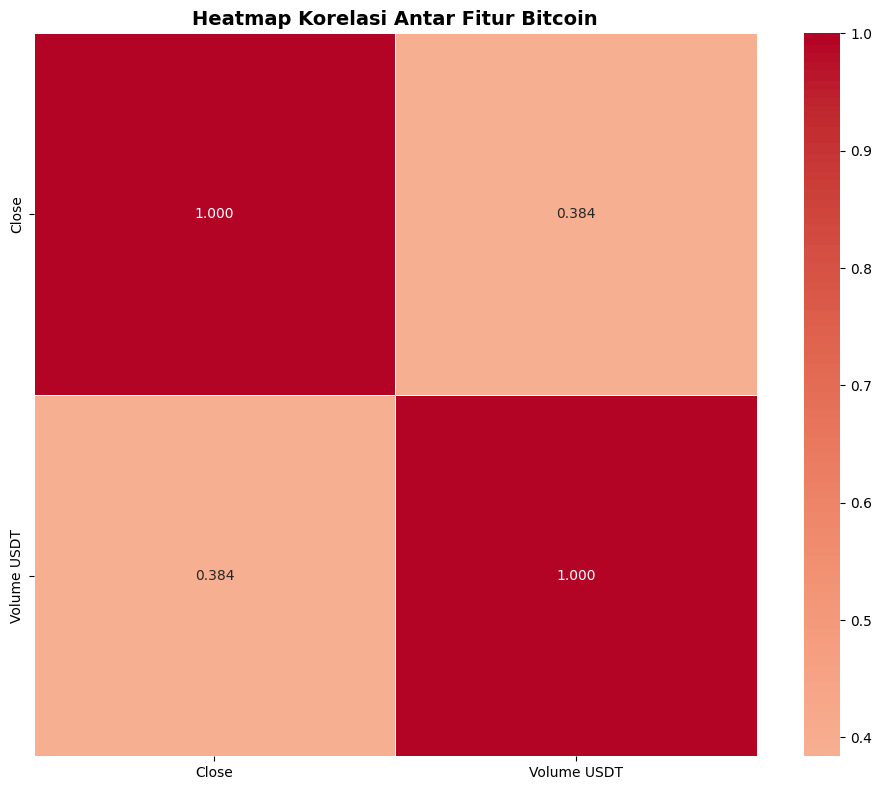


Matriks Korelasi:
               Close  Volume USDT
Close        1.00000      0.38399
Volume USDT  0.38399      1.00000


In [5]:
# Pilih fitur utama untuk model
# Fitur yang digunakan: Open, High, Low, Close, Volume (minimal 3 fitur)
feature_candidates = ['Open', 'High', 'Low', 'Close', 'Volume']

# Cari nama kolom yang cocok (case-insensitive)
available_features = []
col_mapping = {}
for fc in feature_candidates:
    for col in df_numeric.columns:
        if fc.lower() in col.lower():
            available_features.append(col)
            col_mapping[fc] = col
            break

print(f"Fitur yang tersedia: {available_features}")

# Buat heatmap korelasi
plt.figure(figsize=(10, 8))
corr_matrix = df_numeric[available_features].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0,
            fmt='.3f', linewidths=0.5, square=True)
plt.title('Heatmap Korelasi Antar Fitur Bitcoin', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("\nMatriks Korelasi:")
print(corr_matrix)

## Section 5: Time Series Decomposition (Kriteria 1 - Skilled)

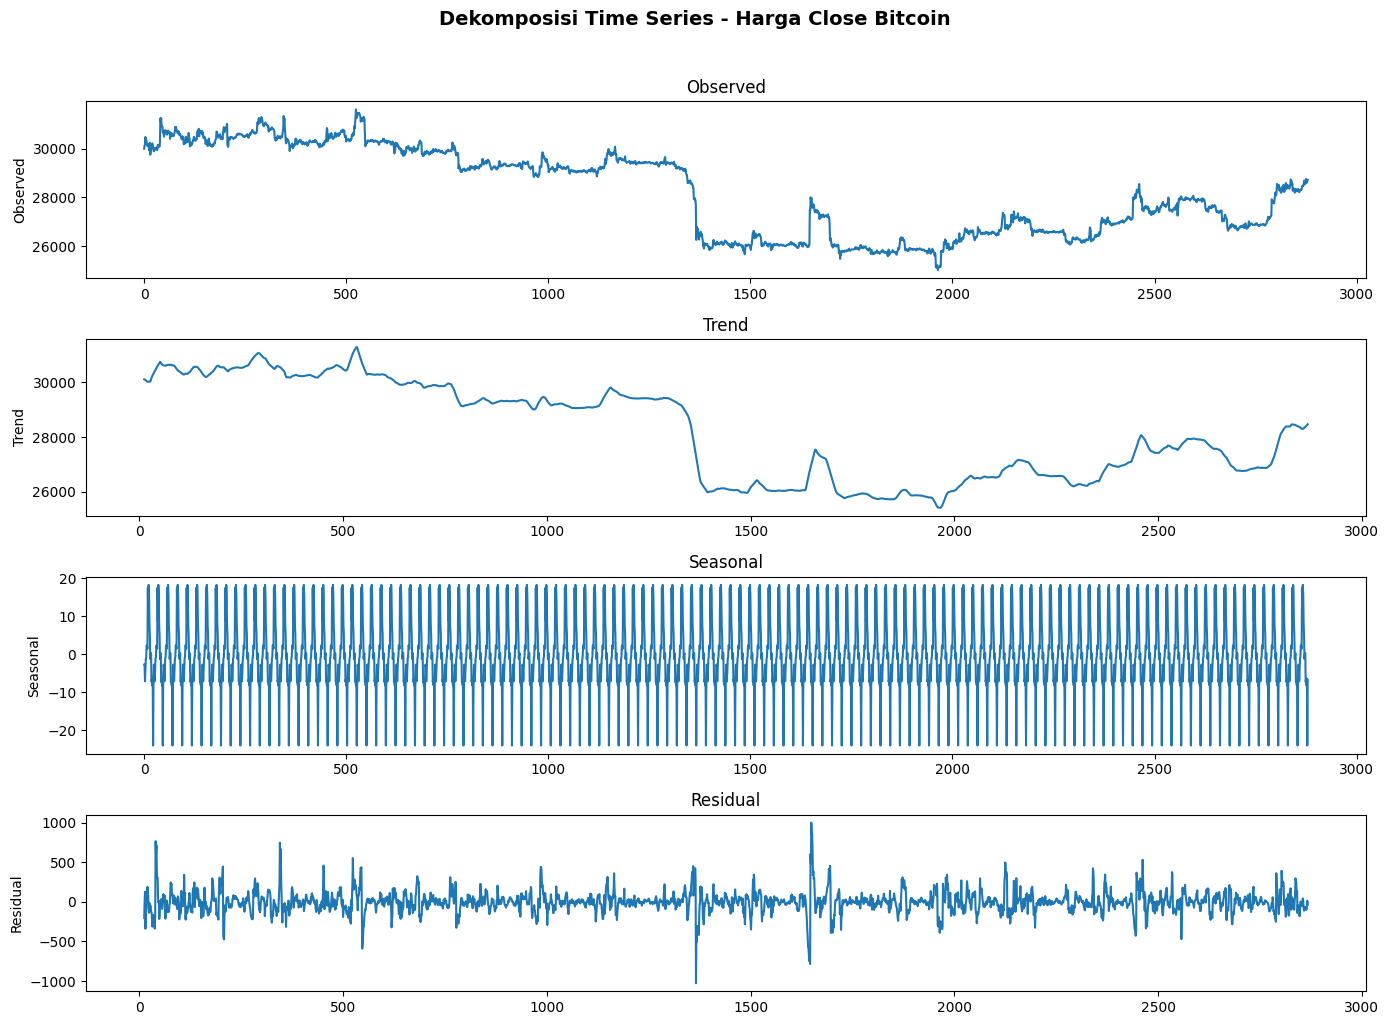

In [6]:
close_col = col_mapping.get('Close', available_features[0])
close_series = df_numeric[close_col].copy()

# Gunakan subset data untuk decomposition (terlalu banyak data bisa lambat)
# Ambil 720 data terakhir (30 hari * 24 jam)
subset_size = min(720 * 4, len(close_series))
close_subset = close_series.iloc[-subset_size:].reset_index(drop=True)

# Analisis dekomposisi
decomposition = seasonal_decompose(close_subset, model='additive', period=24)

fig, axes = plt.subplots(4, 1, figsize=(14, 10))
decomposition.observed.plot(ax=axes[0], title='Observed')
axes[0].set_ylabel('Observed')
decomposition.trend.plot(ax=axes[1], title='Trend')
axes[1].set_ylabel('Trend')
decomposition.seasonal.plot(ax=axes[2], title='Seasonal')
axes[2].set_ylabel('Seasonal')
decomposition.resid.plot(ax=axes[3], title='Residual')
axes[3].set_ylabel('Residual')
plt.suptitle('Dekomposisi Time Series - Harga Close Bitcoin', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## Section 6: Acf & Pacf Analysis (Kriteria 1 - Advanced)

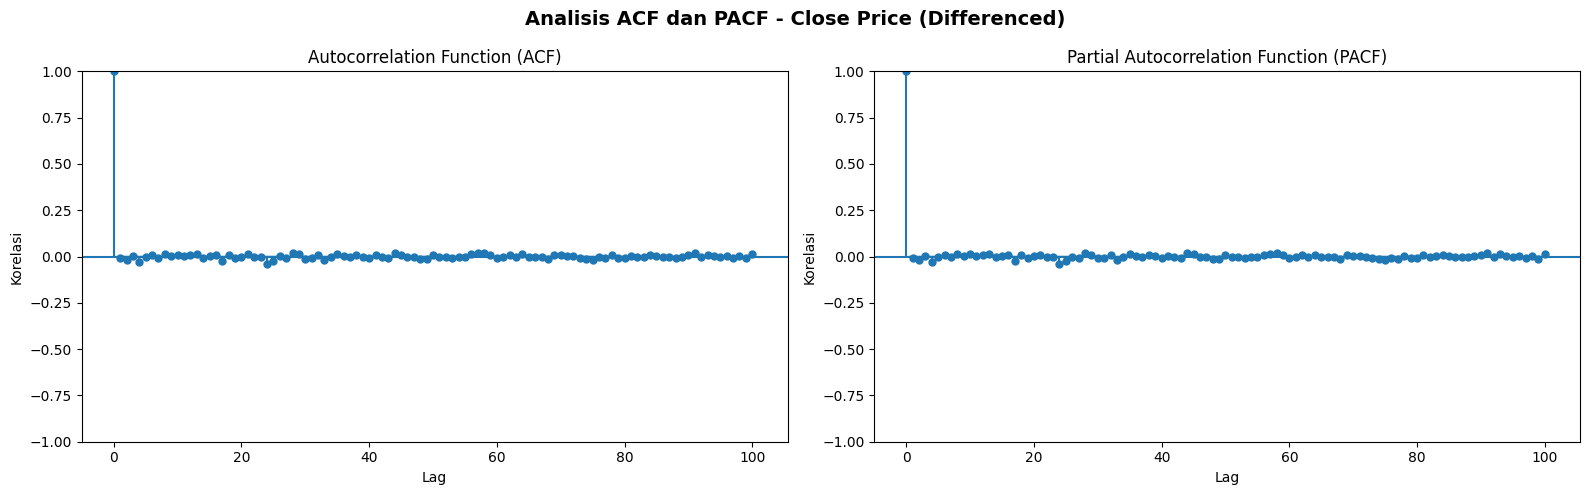


Window Size (ditentukan dari ACF/PACF): 24
Forecast Horizon: 24
Significant PACF lags: [ 0  2  4  6  8 10 12 13 16 17 19 21 24 25 27 28 29 30 33 35]


In [7]:
# Gunakan data close untuk analisis ACF/PACF
# Perlu stationarize dulu dengan differencing
close_diff = close_series.diff().dropna()

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# ACF Plot
plot_acf(close_diff, lags=100, ax=axes[0], title='Autocorrelation Function (ACF)')
axes[0].set_xlabel('Lag')
axes[0].set_ylabel('Korelasi')

# PACF Plot
plot_pacf(close_diff, lags=100, ax=axes[1], title='Partial Autocorrelation Function (PACF)', method='ywm')
axes[1].set_xlabel('Lag')
axes[1].set_ylabel('Korelasi')

plt.suptitle('Analisis ACF dan PACF - Close Price (Differenced)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Tentukan window size berdasarkan PACF
# Cari lag terakhir yang signifikan (di luar confidence interval)
pacf_values = pacf(close_diff, nlags=100, method='ywm')
n = len(close_diff)
confidence_interval = 1.96 / np.sqrt(n)

significant_lags = np.where(np.abs(pacf_values) > confidence_interval)[0]
if len(significant_lags) > 1:
    # Ambil lag signifikan yang masuk akal (antara 24-72)
    reasonable_lags = significant_lags[significant_lags >= 24]
    if len(reasonable_lags) > 0:
        WINDOW_SIZE = int(min(reasonable_lags[0], 72))
    else:
        WINDOW_SIZE = 48  # Default: 2 hari
else:
    WINDOW_SIZE = 48

# Pastikan window size minimal 24 dan maksimal 72
WINDOW_SIZE = max(24, min(WINDOW_SIZE, 72))
FORECAST_HORIZON = 24

print(f"\n{'='*50}")
print(f"Window Size (ditentukan dari ACF/PACF): {WINDOW_SIZE}")
print(f"Forecast Horizon: {FORECAST_HORIZON}")
print(f"Significant PACF lags: {significant_lags[:20]}")
print(f"{'='*50}")

## Section 7: Feature Engineering - Rolling Statistics (Kriteria 1 - Advanced)

In [8]:
# Buat fitur baru menggunakan Rolling Statistics
df_features = df_numeric[available_features].copy()

# Rolling Mean dan Rolling Std pada Close (window=24 jam)
df_features['Close_Rolling_Mean_24'] = df_features[close_col].rolling(window=24, min_periods=1).mean()
df_features['Close_Rolling_Std_24'] = df_features[close_col].rolling(window=24, min_periods=1).std().fillna(0)

# Tambahan: Rolling Mean pada Volume
vol_col = col_mapping.get('Volume', None)
if vol_col:
    df_features['Volume_Rolling_Mean_24'] = df_features[vol_col].rolling(window=24, min_periods=1).mean()

# Hapus baris dengan NaN (dari rolling)
df_features = df_features.dropna().reset_index(drop=True)

print(f"Fitur yang digunakan ({len(df_features.columns)} fitur):")
for i, col in enumerate(df_features.columns):
    print(f"  {i+1}. {col}")
print(f"\nShape: {df_features.shape}")

# Identifikasi indeks kolom Close untuk target
feature_columns = df_features.columns.tolist()
CLOSE_IDX = feature_columns.index(close_col)
N_FEATURES = len(feature_columns)
print(f"\nIndeks kolom Close: {CLOSE_IDX}")
print(f"Jumlah fitur: {N_FEATURES}")

Fitur yang digunakan (5 fitur):
  1. Close
  2. Volume USDT
  3. Close_Rolling_Mean_24
  4. Close_Rolling_Std_24
  5. Volume_Rolling_Mean_24

Shape: (53150, 5)

Indeks kolom Close: 0
Jumlah fitur: 5


## Section 8: Data Splitting & Normalization (Tanpa Data Leakage)

In [9]:
data = df_features.values.astype(np.float32)

# Split: 70% train, 15% validation, 15% test
n = len(data)
train_end = int(n * 0.70)
val_end = int(n * 0.85)

train_data = data[:train_end]
val_data = data[train_end:val_end]
test_data = data[val_end:]

print(f"Train: {train_data.shape} ({train_end} samples)")
print(f"Validation: {val_data.shape} ({val_end - train_end} samples)")
print(f"Test: {test_data.shape} ({n - val_end} samples)")

Train: (37205, 5) (37205 samples)
Validation: (7972, 5) (7972 samples)
Test: (7973, 5) (7973 samples)


In [10]:
# Normalisasi: FIT HANYA PADA DATA TRAIN untuk mencegah data leakage!
scalers = {}
train_scaled = np.zeros_like(train_data)
val_scaled = np.zeros_like(val_data)
test_scaled = np.zeros_like(test_data)

for i, col_name in enumerate(feature_columns):
    scaler = MinMaxScaler(feature_range=(0, 1))
    # FIT hanya pada data train
    train_scaled[:, i] = scaler.fit_transform(train_data[:, i].reshape(-1, 1)).flatten()
    # TRANSFORM val dan test menggunakan scaler yang di-fit dari train
    val_scaled[:, i] = scaler.transform(val_data[:, i].reshape(-1, 1)).flatten()
    test_scaled[:, i] = scaler.transform(test_data[:, i].reshape(-1, 1)).flatten()
    scalers[col_name] = scaler

print("Normalisasi selesai (fit pada train, transform pada val & test)")
print(f"Train scaled range: [{train_scaled.min():.4f}, {train_scaled.max():.4f}]")
print(f"Val scaled range: [{val_scaled.min():.4f}, {val_scaled.max():.4f}]")
print(f"Test scaled range: [{test_scaled.min():.4f}, {test_scaled.max():.4f}]")

# Simpan scaler Close untuk inverse transform nanti
close_scaler = scalers[close_col]

Normalisasi selesai (fit pada train, transform pada val & test)
Train scaled range: [0.0000, 1.0000]
Val scaled range: [0.0048, 1.9846]
Test scaled range: [0.0000, 1.3332]


## Section 9: Data Windowing & Tf.Data.Dataset Pipeline (Kriteria 1 - Skilled)

In [11]:
def create_sequences(data, window_size, forecast_horizon, close_idx):
    """Membuat sequences untuk time series forecasting.

    Returns:
        X: encoder input (samples, window_size, n_features)
        y: target (samples, forecast_horizon) - hanya Close price
    """
    X, y = [], []
    for i in range(len(data) - window_size - forecast_horizon + 1):
        X.append(data[i:i + window_size])
        y.append(data[i + window_size:i + window_size + forecast_horizon, close_idx])
    return np.array(X, dtype=np.float32), np.array(y, dtype=np.float32)

# Buat sequences
X_train, y_train = create_sequences(train_scaled, WINDOW_SIZE, FORECAST_HORIZON, CLOSE_IDX)
X_val, y_val = create_sequences(val_scaled, WINDOW_SIZE, FORECAST_HORIZON, CLOSE_IDX)
X_test, y_test = create_sequences(test_scaled, WINDOW_SIZE, FORECAST_HORIZON, CLOSE_IDX)

print(f"X_train: {X_train.shape}, y_train: {y_train.shape}")
print(f"X_val: {X_val.shape}, y_val: {y_val.shape}")
print(f"X_test: {X_test.shape}, y_test: {y_test.shape}")

X_train: (37158, 24, 5), y_train: (37158, 24)
X_val: (7925, 24, 5), y_val: (7925, 24)
X_test: (7926, 24, 5), y_test: (7926, 24)


In [12]:
# Buat decoder input untuk Seq2Seq (teacher forcing)
# decoder_input = [start_token, y[0], y[1], ..., y[22]] (shifted right)
def create_decoder_input(y):
    """Buat decoder input dengan start token = 0 dan shifted target."""
    decoder_inp = np.zeros((y.shape[0], FORECAST_HORIZON, 1), dtype=np.float32)
    decoder_inp[:, 1:, 0] = y[:, :-1]  # shift right
    return decoder_inp

decoder_train = create_decoder_input(y_train)
decoder_val = create_decoder_input(y_val)
decoder_test = create_decoder_input(y_test)

# Reshape target untuk Seq2Seq: (samples, 24) -> (samples, 24, 1)
y_train_seq = y_train.reshape(-1, FORECAST_HORIZON, 1).astype(np.float32)
y_val_seq = y_val.reshape(-1, FORECAST_HORIZON, 1).astype(np.float32)
y_test_seq = y_test.reshape(-1, FORECAST_HORIZON, 1).astype(np.float32)

print(f"Decoder train input: {decoder_train.shape}")
print(f"y_train_seq: {y_train_seq.shape}")

Decoder train input: (37158, 24, 1)
y_train_seq: (37158, 24, 1)


In [13]:
# tf.data.Dataset Pipeline
BATCH_SIZE = 64
BUFFER_SIZE = 1000

# Dataset untuk Baseline LSTM
train_dataset_baseline = tf.data.Dataset.from_tensor_slices((X_train, y_train))
train_dataset_baseline = train_dataset_baseline.shuffle(BUFFER_SIZE).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

val_dataset_baseline = tf.data.Dataset.from_tensor_slices((X_val, y_val))
val_dataset_baseline = val_dataset_baseline.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

test_dataset_baseline = tf.data.Dataset.from_tensor_slices((X_test, y_test))
test_dataset_baseline = test_dataset_baseline.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

# Dataset untuk Seq2Seq LSTM
train_dataset_seq2seq = tf.data.Dataset.from_tensor_slices(
    ((X_train, decoder_train), y_train_seq))
train_dataset_seq2seq = train_dataset_seq2seq.shuffle(BUFFER_SIZE).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

val_dataset_seq2seq = tf.data.Dataset.from_tensor_slices(
    ((X_val, decoder_val), y_val_seq))
val_dataset_seq2seq = val_dataset_seq2seq.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

test_dataset_seq2seq = tf.data.Dataset.from_tensor_slices(
    ((X_test, decoder_test), y_test_seq))
test_dataset_seq2seq = test_dataset_seq2seq.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

print("tf.data.Dataset pipeline berhasil dibuat!")
print(f"Batch size: {BATCH_SIZE}")

tf.data.Dataset pipeline berhasil dibuat!
Batch size: 64


## Section 10: Custom Layers (Kriteria 2)

In [14]:
# --- 10.1: Custom Dense Layer ---
@tf.keras.utils.register_keras_serializable(package="Custom")
class CustomDense(tf.keras.layers.Layer):
    """Implementasi ulang Dense layer dari nol."""

    def __init__(self, units, activation=None, **kwargs):
        super(CustomDense, self).__init__(**kwargs)
        self.units = units
        self.activation_name = activation
        if activation is not None:
            self.activation_fn = tf.keras.activations.get(activation)
        else:
            self.activation_fn = None

    def build(self, input_shape):
        if input_shape is None:
            return
        self.w = self.add_weight(
            name='kernel',
            shape=(input_shape[-1], self.units),
            initializer='glorot_uniform',
            trainable=True
        )
        self.b = self.add_weight(
            name='bias',
            shape=(self.units,),
            initializer='zeros',
            trainable=True
        )
        super(CustomDense, self).build(input_shape)

    def call(self, inputs):
        output = tf.matmul(inputs, self.w) + self.b
        if self.activation_fn is not None:
            output = self.activation_fn(output)
        return output

    def get_config(self):
        config = super(CustomDense, self).get_config()
        config.update({
            'units': self.units,
            'activation': self.activation_name,
        })
        return config


# --- 10.2: Custom Dropout Layer (Advanced) ---
@tf.keras.utils.register_keras_serializable(package="Custom")
class CustomDropout(tf.keras.layers.Layer):
    """Implementasi ulang Dropout layer dari nol."""

    def __init__(self, rate=0.1, **kwargs):
        super(CustomDropout, self).__init__(**kwargs)
        self.rate = rate

    def call(self, inputs, training=None):
        if training is None:
            training = False

        def dropped():
            mask = tf.cast(
                tf.random.uniform(tf.shape(inputs)) >= self.rate,
                dtype=inputs.dtype
            )
            return inputs * mask / (1.0 - self.rate)

        return tf.cond(tf.cast(training, tf.bool), dropped, lambda: inputs)

    def get_config(self):
        config = super(CustomDropout, self).get_config()
        config.update({'rate': self.rate})
        return config


# --- 10.3: Custom Layer Normalization (Advanced) ---
@tf.keras.utils.register_keras_serializable(package="Custom")
class CustomLayerNormalization(tf.keras.layers.Layer):
    """Implementasi ulang LayerNormalization dari nol."""

    def __init__(self, epsilon=1e-6, **kwargs):
        super(CustomLayerNormalization, self).__init__(**kwargs)
        self.epsilon = epsilon

    def build(self, input_shape):
        if input_shape is None:
            return
        self.gamma = self.add_weight(
            name='gamma',
            shape=(input_shape[-1],),
            initializer='ones',
            trainable=True
        )
        self.beta = self.add_weight(
            name='beta',
            shape=(input_shape[-1],),
            initializer='zeros',
            trainable=True
        )
        super(CustomLayerNormalization, self).build(input_shape)

    def call(self, inputs):
        mean = tf.reduce_mean(inputs, axis=-1, keepdims=True)
        variance = tf.math.reduce_variance(inputs, axis=-1, keepdims=True)
        normalized = (inputs - mean) / tf.sqrt(variance + self.epsilon)
        return self.gamma * normalized + self.beta

    def get_config(self):
        config = super(CustomLayerNormalization, self).get_config()
        config.update({'epsilon': self.epsilon})
        return config


# --- 10.4: Custom Multi-Head Attention Layer (Advanced) ---
@tf.keras.utils.register_keras_serializable(package="Custom")
class CustomMultiHeadAttention(tf.keras.layers.Layer):
    """Implementasi ulang Multi-Head Attention dari nol."""

    def __init__(self, num_heads=4, key_dim=32, **kwargs):
        super(CustomMultiHeadAttention, self).__init__(**kwargs)
        self.num_heads = num_heads
        self.key_dim = key_dim
        self.d_model = num_heads * key_dim

    def build(self, input_shape):
        if input_shape is None:
            return
        if isinstance(input_shape, list) and isinstance(input_shape[0], (list, tuple, tf.TensorShape)):
            feat_dim = input_shape[0][-1]
        else:
            feat_dim = input_shape[-1]

        self.wq = self.add_weight(name='wq', shape=(feat_dim, self.d_model),
                                  initializer='glorot_uniform', trainable=True)
        self.wk = self.add_weight(name='wk', shape=(feat_dim, self.d_model),
                                  initializer='glorot_uniform', trainable=True)
        self.wv = self.add_weight(name='wv', shape=(feat_dim, self.d_model),
                                  initializer='glorot_uniform', trainable=True)
        self.wo = self.add_weight(name='wo', shape=(self.d_model, feat_dim),
                                  initializer='glorot_uniform', trainable=True)

        super(CustomMultiHeadAttention, self).build(input_shape)

    def _split_heads(self, x):
        """Split the last dimension into (num_heads, key_dim)."""
        shape = tf.shape(x)
        x = tf.reshape(x, (-1, shape[1], self.num_heads, self.key_dim))
        return tf.transpose(x, perm=[0, 2, 1, 3])

    def _scaled_dot_product_attention(self, q, k, v):
        """Scaled Dot-Product Attention."""
        matmul_qk = tf.matmul(q, k, transpose_b=True)
        dk = tf.cast(tf.shape(k)[-1], dtype=tf.float32)
        scaled_attention_logits = matmul_qk / tf.math.sqrt(dk)
        attention_weights = tf.nn.softmax(scaled_attention_logits, axis=-1)
        output = tf.matmul(attention_weights, v)
        return output

    def call(self, query, key=None, value=None):
        if key is None:
            key = query
        if value is None:
            value = query

        q = tf.matmul(query, self.wq)
        k = tf.matmul(key, self.wk)
        v = tf.matmul(value, self.wv)

        q = self._split_heads(q)
        k = self._split_heads(k)
        v = self._split_heads(v)

        attention_output = self._scaled_dot_product_attention(q, k, v)
        attention_output = tf.transpose(attention_output, perm=[0, 2, 1, 3])

        shape = tf.shape(attention_output)
        concat_attention = tf.reshape(attention_output,
                                      (-1, shape[1], self.d_model))

        output = tf.matmul(concat_attention, self.wo)
        return output

    def get_config(self):
        config = super(CustomMultiHeadAttention, self).get_config()
        config.update({
            'num_heads': self.num_heads,
            'key_dim': self.key_dim,
        })
        return config

print("Semua Custom Layer berhasil didefinisikan!")
print("  - CustomDense")
print("  - CustomDropout")
print("  - CustomLayerNormalization")
print("  - CustomMultiHeadAttention")

Semua Custom Layer berhasil didefinisikan!
  - CustomDense
  - CustomDropout
  - CustomLayerNormalization
  - CustomMultiHeadAttention


## Section 11: Model Baseline Lstm (Kriteria 1 & 2)

In [15]:
def build_baseline_lstm(window_size, n_features, forecast_horizon, lstm_units=128):
    """Baseline LSTM dengan Custom Layers dan Multi-Head Attention."""
    inputs = tf.keras.Input(shape=(window_size, n_features), name='input')

    # LSTM Layer
    x = tf.keras.layers.LSTM(lstm_units, return_sequences=True, name='lstm_1')(inputs)
    x = tf.keras.layers.LSTM(lstm_units, return_sequences=True, name='lstm_2')(x)

    # Custom Multi-Head Attention (self-attention)
    attn_out = CustomMultiHeadAttention(num_heads=4, key_dim=32, name='custom_mha')(x)
    attn_out = CustomDropout(rate=0.2, name='custom_dropout_1')(attn_out)

    # Gunakan tf.keras.layers.Add() untuk menghindari masalah serialization TFOpLambda di Keras 3
    added = tf.keras.layers.Add()([x, attn_out])
    x = CustomLayerNormalization(name='custom_layernorm_1')(added)  # Residual

    # Flatten dan prediksi
    x = tf.keras.layers.Flatten(name='flatten')(x)
    x = CustomDense(256, activation='relu', name='custom_dense_1')(x)
    x = CustomDropout(rate=0.2, name='custom_dropout_2')(x)
    outputs = CustomDense(forecast_horizon, name='custom_dense_output')(x)

    model = tf.keras.Model(inputs=inputs, outputs=outputs, name='baseline_lstm')
    return model

model_baseline = build_baseline_lstm(WINDOW_SIZE, N_FEATURES, FORECAST_HORIZON)
model_baseline.summary()

Model: "baseline_lstm"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input (InputLayer)  │ (None, 24, 5)     │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_1 (LSTM)       │ (None, 24, 128)   │     68,608 │ input[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_2 (LSTM)       │ (None, 24, 128)   │    131,584 │ lstm_1[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ custom_mha          │ (None, 24, 128)   │     65,536 │ lstm_2[0][0]      │
│ (CustomMultiHeadAt… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ custom_dropout_1    │ (None, 24, 128)   │          0 │ custom_mha[0][0]  │
│ (CustomDropout)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 24, 128)   │          0 │ lstm_2[0][0],     │
│                     │                   │            │ custom_dropout_1… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ custom_layernorm_1  │ (None, 24, 128)   │        256 │ add[0][0]         │
│ (CustomLayerNormal… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten (Flatten)   │ (None, 3072)      │          0 │ custom_layernorm… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ custom_dense_1      │ (None, 256)       │    786,688 │ flatten[0][0]     │
│ (CustomDense)       │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ custom_dropout_2    │ (None, 256)       │          0 │ custom_dense_1[0… │
│ (CustomDropout)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ custom_dense_output │ (None, 24)        │      6,168 │ custom_dropout_2… │
│ (CustomDense)       │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 1,058,840 (4.04 MB)

 Trainable params: 1,058,840 (4.04 MB)

 Non-trainable params: 0 (0.00 B)

## Section 12: Seq2Seq Lstm - Functional Api (Kriteria 2 - Basic)

In [16]:
def build_seq2seq_functional(window_size, n_features, forecast_horizon, lstm_units=128):
    """Seq2Seq LSTM dengan Teacher Forcing menggunakan Functional API."""

    # --- ENCODER ---
    encoder_inputs = tf.keras.Input(shape=(window_size, n_features), name='encoder_input')
    encoder_lstm_1 = tf.keras.layers.LSTM(lstm_units, return_sequences=True, name='encoder_lstm_1')
    encoder_out = encoder_lstm_1(encoder_inputs)

    # Self-attention pada encoder
    encoder_attn = CustomMultiHeadAttention(num_heads=4, key_dim=32, name='encoder_mha')(encoder_out)
    encoder_attn = CustomDropout(rate=0.1, name='encoder_dropout')(encoder_attn)

    # Gunakan tf.keras.layers.Add() untuk menghindari masalah serialization TFOpLambda di Keras 3
    added = tf.keras.layers.Add()([encoder_out, encoder_attn])
    encoder_out = CustomLayerNormalization(name='encoder_layernorm')(added)

    encoder_lstm_2 = tf.keras.layers.LSTM(lstm_units, return_state=True, name='encoder_lstm_2')
    encoder_outputs, state_h, state_c = encoder_lstm_2(encoder_out)
    encoder_states = [state_h, state_c]

    # --- DECODER ---
    decoder_inputs = tf.keras.Input(shape=(forecast_horizon, 1), name='decoder_input')
    decoder_lstm = tf.keras.layers.LSTM(lstm_units, return_sequences=True,
                                        return_state=True, name='decoder_lstm')
    decoder_outputs, _, _ = decoder_lstm(decoder_inputs, initial_state=encoder_states)

    # Custom layers pada decoder output
    decoder_outputs = CustomDropout(rate=0.1, name='decoder_dropout')(decoder_outputs)
    decoder_outputs = CustomLayerNormalization(name='decoder_layernorm')(decoder_outputs)
    decoder_outputs = CustomDense(1, name='decoder_dense_output')(decoder_outputs)

    model = tf.keras.Model(
        inputs=[encoder_inputs, decoder_inputs],
        outputs=decoder_outputs,
        name='seq2seq_lstm_functional'
    )
    return model

model_seq2seq_func = build_seq2seq_functional(WINDOW_SIZE, N_FEATURES, FORECAST_HORIZON)
model_seq2seq_func.summary()

Model: "seq2seq_lstm_functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ encoder_input       │ (None, 24, 5)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ encoder_lstm_1      │ (None, 24, 128)   │     68,608 │ encoder_input[0]… │
│ (LSTM)              │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ encoder_mha         │ (None, 24, 128)   │     65,536 │ encoder_lstm_1[0… │
│ (CustomMultiHeadAt… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ encoder_dropout     │ (None, 24, 128)   │          0 │ encoder_mha[0][0] │
│ (CustomDropout)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 24, 128)   │          0 │ encoder_lstm_1[0… │
│                     │                   │            │ encoder_dropout[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ encoder_layernorm   │ (None, 24, 128)   │        256 │ add_1[0][0]       │
│ (CustomLayerNormal… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ decoder_input       │ (None, 24, 1)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ encoder_lstm_2      │ [(None, 128),     │    131,584 │ encoder_layernor… │
│ (LSTM)              │ (None, 128),      │            │                   │
│                     │ (None, 128)]      │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ decoder_lstm (LSTM) │ [(None, 24, 128), │     66,560 │ decoder_input[0]… │
│                     │ (None, 128),      │            │ encoder_lstm_2[0… │
│                     │ (None, 128)]      │            │ encoder_lstm_2[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ decoder_dropout     │ (None, 24, 128)   │          0 │ decoder_lstm[0][… │
│ (CustomDropout)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ decoder_layernorm   │ (None, 24, 128)   │        256 │ decoder_dropout[… │
│ (CustomLayerNormal… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ decoder_dense_outp… │ (None, 24, 1)     │        129 │ decoder_layernor… │
│ (CustomDense)       │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 332,929 (1.27 MB)

 Trainable params: 332,929 (1.27 MB)

 Non-trainable params: 0 (0.00 B)

## Section 13: Seq2Seq Lstm - Model Subclassing (Kriteria 2 - Skilled)

In [17]:
@tf.keras.utils.register_keras_serializable(package="Custom")
class Seq2SeqLSTMSubclassed(tf.keras.Model):
    """Seq2Seq LSTM dengan Teacher Forcing menggunakan Model Subclassing."""

    def __init__(self, lstm_units=128, forecast_horizon=24, n_features=1, **kwargs):
        super(Seq2SeqLSTMSubclassed, self).__init__(**kwargs)
        self.lstm_units = lstm_units
        self.forecast_horizon = forecast_horizon
        self.n_features_init = n_features

        # Encoder
        self.encoder_lstm_1 = tf.keras.layers.LSTM(lstm_units, return_sequences=True,
                                                    name='enc_lstm_1')
        self.encoder_mha = CustomMultiHeadAttention(num_heads=4, key_dim=32, name='enc_mha')
        self.encoder_dropout = CustomDropout(rate=0.1, name='enc_dropout')
        self.encoder_layernorm = CustomLayerNormalization(name='enc_layernorm')
        self.encoder_lstm_2 = tf.keras.layers.LSTM(lstm_units, return_state=True,
                                                    name='enc_lstm_2')

        # Decoder
        self.decoder_lstm = tf.keras.layers.LSTM(lstm_units, return_sequences=True,
                                                  return_state=True, name='dec_lstm')
        self.decoder_dropout = CustomDropout(rate=0.1, name='dec_dropout')
        self.decoder_layernorm = CustomLayerNormalization(name='dec_layernorm')
        self.decoder_dense = CustomDense(1, name='dec_dense')

    def call(self, inputs, training=None):
        if isinstance(inputs, (list, tuple)):
            encoder_input, decoder_input = inputs
        else:
            encoder_input = inputs
            decoder_input = tf.zeros((tf.shape(encoder_input)[0],
                                      self.forecast_horizon, 1))

        # Encoder
        enc_out = self.encoder_lstm_1(encoder_input, training=training)
        enc_attn = self.encoder_mha(enc_out)
        enc_attn = self.encoder_dropout(enc_attn, training=training)
        enc_out = self.encoder_layernorm(enc_out + enc_attn)
        _, state_h, state_c = self.encoder_lstm_2(enc_out, training=training)

        # Decoder
        dec_out, _, _ = self.decoder_lstm(decoder_input,
                                          initial_state=[state_h, state_c],
                                          training=training)
        dec_out = self.decoder_dropout(dec_out, training=training)
        dec_out = self.decoder_layernorm(dec_out)
        output = self.decoder_dense(dec_out)
        return output

    def get_config(self):
        config = super(Seq2SeqLSTMSubclassed, self).get_config()
        config.update({
            'lstm_units': self.lstm_units,
            'forecast_horizon': self.forecast_horizon,
            'n_features': self.n_features_init,
        })
        return config

model_seq2seq_sub = Seq2SeqLSTMSubclassed(
    lstm_units=128,
    forecast_horizon=FORECAST_HORIZON,
    n_features=N_FEATURES
)

# Build model by calling it once
dummy_enc = tf.zeros((1, WINDOW_SIZE, N_FEATURES))
dummy_dec = tf.zeros((1, FORECAST_HORIZON, 1))
_ = model_seq2seq_sub([dummy_enc, dummy_dec])
model_seq2seq_sub.summary()

Model: "seq2_seq_lstm_subclassed"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ enc_lstm_1 (LSTM)               │ (1, 24, 128)           │        68,608 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ enc_mha                         │ ?                      │        65,536 │
│ (CustomMultiHeadAttention)      │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ enc_dropout (CustomDropout)     │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ enc_layernorm                   │ ?                      │           256 │
│ (CustomLayerNormalization)      │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ enc_lstm_2 (LSTM)               │ ((1, 128), (1, 128),   │       131,584 │
│                                 │ (1, 128))              │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dec_lstm (LSTM)                 │ ((1, 24, 128), (1,     │        66,560 │
│                                 │ 128), (1, 128))        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dec_dropout (CustomDropout)     │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dec_layernorm                   │ ?                      │           256 │
│ (CustomLayerNormalization)      │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dec_dense (CustomDense)         │ ?                      │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 332,929 (1.27 MB)

 Trainable params: 332,929 (1.27 MB)

 Non-trainable params: 0 (0.00 B)

## Section 14: Custom Loss Functions (Kriteria 3)

In [18]:
# --- 14.1: Custom MAE Loss (Skilled) ---
def custom_mae_loss(y_true, y_pred):
    """Implementasi MAE Loss dari nol."""
    y_true = tf.cast(y_true, tf.float32)
    y_pred = tf.cast(y_pred, tf.float32)
    absolute_errors = tf.abs(y_true - y_pred)
    return tf.reduce_mean(absolute_errors)


# --- 14.2: Custom Weighted MAE Loss (Advanced) ---
def custom_weighted_mae_loss(y_true, y_pred):
    """MAE Loss dengan bobot yang meningkat pada horizon yang lebih jauh.

    Step ke-1 bobot 1.0, step terakhir bobot ~2.0 (linear increase).
    """
    y_true = tf.cast(y_true, tf.float32)
    y_pred = tf.cast(y_pred, tf.float32)

    # Buat weights yang meningkat linear dari 1.0 ke 2.0
    n_steps = tf.shape(y_true)[-1] if len(y_true.shape) == 2 else tf.shape(y_true)[-2]
    n_steps = tf.cast(n_steps, tf.float32)
    weights = tf.linspace(1.0, 2.0, tf.cast(n_steps, tf.int32))

    # Sesuaikan shape weights dengan y_true
    if len(y_true.shape) == 3:  # (batch, horizon, 1)
        weights = tf.reshape(weights, (1, -1, 1))
    else:  # (batch, horizon)
        weights = tf.reshape(weights, (1, -1))

    absolute_errors = tf.abs(y_true - y_pred)
    weighted_errors = absolute_errors * weights
    return tf.reduce_mean(weighted_errors)

print("Custom Loss Functions:")
print("  - custom_mae_loss (Skilled)")
print("  - custom_weighted_mae_loss (Advanced)")

Custom Loss Functions:
  - custom_mae_loss (Skilled)
  - custom_weighted_mae_loss (Advanced)


## Section 15: Custom Callbacks (Kriteria 3)

In [19]:
# --- 15.1: Custom Early Stopping (Skilled) ---
class CustomEarlyStopping:
    """Implementasi Early Stopping dari nol."""

    def __init__(self, patience=10, min_delta=1e-5, restore_best_weights=True):
        self.patience = patience
        self.min_delta = min_delta
        self.restore_best_weights = restore_best_weights
        self.best_loss = float('inf')
        self.wait = 0
        self.best_weights = None
        self.stopped = False

    def on_epoch_end(self, epoch, val_loss, model):
        if val_loss < (self.best_loss - self.min_delta):
            self.best_loss = val_loss
            self.wait = 0
            if self.restore_best_weights:
                self.best_weights = model.get_weights()
        else:
            self.wait += 1
            if self.wait >= self.patience:
                self.stopped = True
                if self.restore_best_weights and self.best_weights is not None:
                    model.set_weights(self.best_weights)
                    print(f"\n  [EarlyStopping] Restoring best weights dari epoch {epoch - self.wait + 1}")
                print(f"  [EarlyStopping] Training dihentikan pada epoch {epoch + 1}")

    def reset(self):
        self.best_loss = float('inf')
        self.wait = 0
        self.best_weights = None
        self.stopped = False


# --- 15.2: Custom Reduce LR on Plateau (Advanced) ---
class CustomReduceLROnPlateau:
    """Custom callback untuk mengurangi learning rate saat val_loss stagnan."""

    def __init__(self, optimizer, patience=5, factor=0.5, min_lr=1e-7, verbose=True):
        self.optimizer = optimizer
        self.patience = patience
        self.factor = factor
        self.min_lr = min_lr
        self.verbose = verbose
        self.best_loss = float('inf')
        self.wait = 0

    def on_epoch_end(self, epoch, val_loss):
        if val_loss < self.best_loss:
            self.best_loss = val_loss
            self.wait = 0
        else:
            self.wait += 1
            if self.wait >= self.patience:
                current_lr = float(self.optimizer.learning_rate.numpy())
                new_lr = max(current_lr * self.factor, self.min_lr)
                if new_lr < current_lr:
                    self.optimizer.learning_rate.assign(new_lr)
                    if self.verbose:
                        print(f"  [ReduceLR] LR dikurangi: {current_lr:.2e} → {new_lr:.2e}")
                    self.wait = 0

    def reset(self):
        self.best_loss = float('inf')
        self.wait = 0

print("Custom Callbacks:")
print("  - CustomEarlyStopping (Skilled)")
print("  - CustomReduceLROnPlateau (Advanced)")

Custom Callbacks:
  - CustomEarlyStopping (Skilled)
  - CustomReduceLROnPlateau (Advanced)


## Section 16: Custom Training Loop (Kriteria 3)

In [20]:
# --- 16.1: Training step functions ---
@tf.function
def train_step_baseline(model, x, y, optimizer, loss_fn):
    """Single training step untuk baseline LSTM."""
    with tf.GradientTape() as tape:
        predictions = model(x, training=True)
        loss = loss_fn(y, predictions)
    gradients = tape.gradient(loss, model.trainable_variables)
    optimizer.apply_gradients(zip(gradients, model.trainable_variables))
    return loss

@tf.function
def val_step_baseline(model, x, y, loss_fn):
    """Single validation step untuk baseline LSTM."""
    predictions = model(x, training=False)
    return loss_fn(y, predictions)

@tf.function
def train_step_seq2seq(model, encoder_input, decoder_input, target, optimizer, loss_fn):
    """Single training step untuk Seq2Seq LSTM."""
    with tf.GradientTape() as tape:
        predictions = model([encoder_input, decoder_input], training=True)
        loss = loss_fn(target, predictions)
    gradients = tape.gradient(loss, model.trainable_variables)
    optimizer.apply_gradients(zip(gradients, model.trainable_variables))
    return loss

@tf.function
def val_step_seq2seq(model, encoder_input, decoder_input, target, loss_fn):
    """Single validation step untuk Seq2Seq LSTM."""
    predictions = model([encoder_input, decoder_input], training=False)
    return loss_fn(target, predictions)


# --- 16.2: Main training function ---
def custom_train(model, train_dataset, val_dataset, optimizer, loss_fn,
                 epochs, model_type='baseline', callbacks=None):
    """Custom Training Loop dengan tf.GradientTape yang dioptimasi (Inlined)."""
    history = {'loss': [], 'val_loss': []}

    if callbacks is None:
        callbacks = {}

    early_stopping = callbacks.get('early_stopping', None)
    reduce_lr = callbacks.get('reduce_lr', None)

    # Initialize optimizer variables to avoid tf.function error in Keras 3
    if hasattr(optimizer, 'build'):
        try:
            optimizer.build(model.trainable_variables)
        except Exception:
            pass

    # --- FUNGSI OPTIMASI EPOCH (Inlined GradientTape untuk menghindari retracing) ---
    @tf.function
    def train_epoch_baseline_fast(train_ds):
        total_loss = tf.constant(0.0)
        batches = tf.constant(0.0)
        for x_batch, y_batch in train_ds:
            with tf.GradientTape() as tape:
                predictions = model(x_batch, training=True)
                loss = loss_fn(y_batch, predictions)
            gradients = tape.gradient(loss, model.trainable_variables)
            optimizer.apply_gradients(zip(gradients, model.trainable_variables))

            total_loss += loss
            batches += 1.0
        return total_loss / batches if batches > 0 else total_loss

    @tf.function
    def val_epoch_baseline_fast(val_ds):
        total_loss = tf.constant(0.0)
        batches = tf.constant(0.0)
        for x_batch, y_batch in val_ds:
            predictions = model(x_batch, training=False)
            v_loss = loss_fn(y_batch, predictions)
            total_loss += v_loss
            batches += 1.0
        return total_loss / batches if batches > 0 else total_loss

    @tf.function
    def train_epoch_seq2seq_fast(train_ds):
        total_loss = tf.constant(0.0)
        batches = tf.constant(0.0)
        for batch_data in train_ds:
            inputs, target_batch = batch_data
            enc_batch = inputs[0]
            dec_batch = inputs[1]

            with tf.GradientTape() as tape:
                predictions = model([enc_batch, dec_batch], training=True)
                loss = loss_fn(target_batch, predictions)
            gradients = tape.gradient(loss, model.trainable_variables)
            optimizer.apply_gradients(zip(gradients, model.trainable_variables))

            total_loss += loss
            batches += 1.0
        return total_loss / batches if batches > 0 else total_loss

    @tf.function
    def val_epoch_seq2seq_fast(val_ds):
        total_loss = tf.constant(0.0)
        batches = tf.constant(0.0)
        for batch_data in val_ds:
            inputs, target_batch = batch_data
            enc_batch = inputs[0]
            dec_batch = inputs[1]

            predictions = model([enc_batch, dec_batch], training=False)
            v_loss = loss_fn(target_batch, predictions)

            total_loss += v_loss
            batches += 1.0
        return total_loss / batches if batches > 0 else total_loss
    # ---------------------------------------------------------------------

    for epoch in range(epochs):
        # Eksekusi epoch penuh secara vektorisasi
        if model_type == 'baseline':
            avg_train_loss = train_epoch_baseline_fast(train_dataset)
            avg_val_loss = val_epoch_baseline_fast(val_dataset)
        else:
            avg_train_loss = train_epoch_seq2seq_fast(train_dataset)
            avg_val_loss = val_epoch_seq2seq_fast(val_dataset)

        avg_train_loss = float(avg_train_loss)
        avg_val_loss = float(avg_val_loss)

        history['loss'].append(avg_train_loss)
        history['val_loss'].append(avg_val_loss)

        # Print progress
        current_lr = float(optimizer.learning_rate.numpy())
        print(f"Epoch {epoch+1}/{epochs} - "
              f"loss: {avg_train_loss:.6f} - "
              f"val_loss: {avg_val_loss:.6f} - "
              f"lr: {current_lr:.2e}")

        # Callbacks
        if reduce_lr:
            reduce_lr.on_epoch_end(epoch, avg_val_loss)

        if early_stopping:
            early_stopping.on_epoch_end(epoch, avg_val_loss, model)
            if early_stopping.stopped:
                break

    return history

## Section 17: Training Baseline Lstm

In [21]:
print("=" * 60)
print("TRAINING MODEL 1: BASELINE LSTM")
print("=" * 60)

optimizer_baseline = tf.keras.optimizers.Adam(learning_rate=0.001)

early_stop_baseline = CustomEarlyStopping(patience=15, restore_best_weights=True)
reduce_lr_baseline = CustomReduceLROnPlateau(optimizer_baseline, patience=7, factor=0.5)

history_baseline = custom_train(
    model=model_baseline,
    train_dataset=train_dataset_baseline,
    val_dataset=val_dataset_baseline,
    optimizer=optimizer_baseline,
    loss_fn=custom_weighted_mae_loss,
    epochs=80,
    model_type='baseline',
    callbacks={
        'early_stopping': early_stop_baseline,
        'reduce_lr': reduce_lr_baseline,
    }
)

TRAINING MODEL 1: BASELINE LSTM
Epoch 1/80 - loss: 0.209771 - val_loss: 0.214713 - lr: 1.00e-03
Epoch 2/80 - loss: 0.261918 - val_loss: 0.216966 - lr: 1.00e-03
Epoch 3/80 - loss: 0.253098 - val_loss: 0.218232 - lr: 1.00e-03
Epoch 4/80 - loss: 0.251000 - val_loss: 0.218664 - lr: 1.00e-03
Epoch 5/80 - loss: 0.250143 - val_loss: 0.218706 - lr: 1.00e-03
Epoch 6/80 - loss: 0.250561 - val_loss: 0.218985 - lr: 1.00e-03
Epoch 7/80 - loss: 0.250188 - val_loss: 0.219012 - lr: 1.00e-03
Epoch 8/80 - loss: 0.249984 - val_loss: 0.218976 - lr: 1.00e-03
  [ReduceLR] LR dikurangi: 1.00e-03 → 5.00e-04
Epoch 9/80 - loss: 0.317153 - val_loss: 0.326679 - lr: 5.00e-04
Epoch 10/80 - loss: 0.247690 - val_loss: 0.321528 - lr: 5.00e-04
Epoch 11/80 - loss: 0.248402 - val_loss: 0.319570 - lr: 5.00e-04
Epoch 12/80 - loss: 0.248715 - val_loss: 0.318656 - lr: 5.00e-04
Epoch 13/80 - loss: 0.248554 - val_loss: 0.317474 - lr: 5.00e-04
Epoch 14/80 - loss: 0.249027 - val_loss: 0.317665 - lr: 5.00e-04
Epoch 15/80 - loss: 

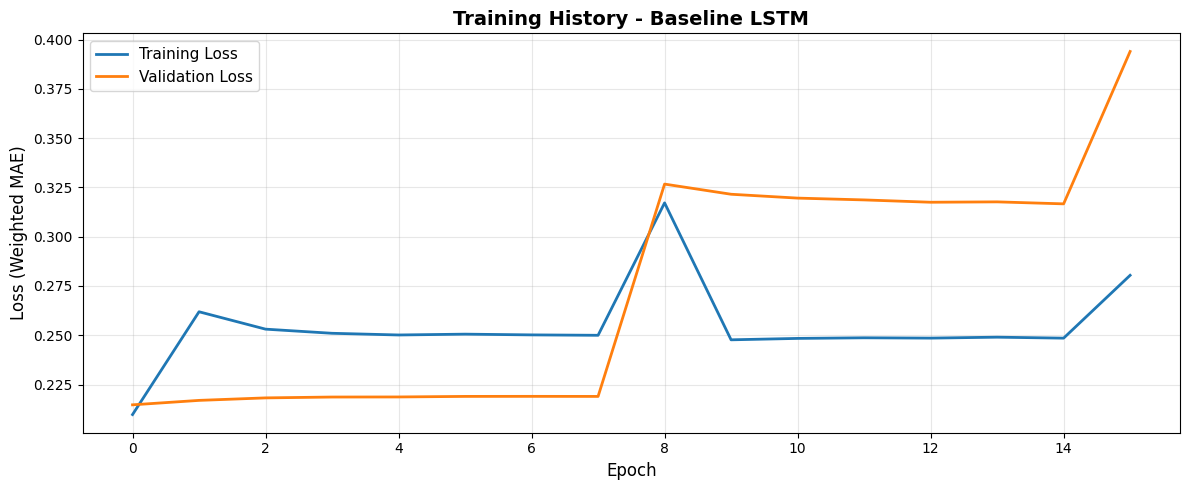

In [22]:
# Plot training history baseline
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(history_baseline['loss'], label='Training Loss', linewidth=2)
ax.plot(history_baseline['val_loss'], label='Validation Loss', linewidth=2)
ax.set_xlabel('Epoch', fontsize=12)
ax.set_ylabel('Loss (Weighted MAE)', fontsize=12)
ax.set_title('Training History - Baseline LSTM', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Section 18: Training Seq2Seq Lstm (Functional Api)

In [23]:
print("=" * 60)
print("TRAINING MODEL 2: SEQ2SEQ LSTM (Functional API + Teacher Forcing)")
print("=" * 60)

optimizer_seq2seq = tf.keras.optimizers.Adam(learning_rate=0.001)

early_stop_seq2seq = CustomEarlyStopping(patience=15, restore_best_weights=True)
reduce_lr_seq2seq = CustomReduceLROnPlateau(optimizer_seq2seq, patience=7, factor=0.5)

history_seq2seq = custom_train(
    model=model_seq2seq_func,
    train_dataset=train_dataset_seq2seq,
    val_dataset=val_dataset_seq2seq,
    optimizer=optimizer_seq2seq,
    loss_fn=custom_weighted_mae_loss,
    epochs=80,
    model_type='seq2seq',
    callbacks={
        'early_stopping': early_stop_seq2seq,
        'reduce_lr': reduce_lr_seq2seq,
    }
)

TRAINING MODEL 2: SEQ2SEQ LSTM (Functional API + Teacher Forcing)
Epoch 1/80 - loss: 0.152634 - val_loss: 0.014106 - lr: 1.00e-03
Epoch 2/80 - loss: 0.026793 - val_loss: 0.029061 - lr: 1.00e-03
Epoch 3/80 - loss: 0.019483 - val_loss: 0.047297 - lr: 1.00e-03
Epoch 4/80 - loss: 0.020237 - val_loss: 0.042702 - lr: 1.00e-03
Epoch 5/80 - loss: 0.019585 - val_loss: 0.043590 - lr: 1.00e-03
Epoch 6/80 - loss: 0.018043 - val_loss: 0.031175 - lr: 1.00e-03
Epoch 7/80 - loss: 0.016493 - val_loss: 0.037541 - lr: 1.00e-03
Epoch 8/80 - loss: 0.019187 - val_loss: 0.040410 - lr: 1.00e-03
  [ReduceLR] LR dikurangi: 1.00e-03 → 5.00e-04
Epoch 9/80 - loss: 0.014906 - val_loss: 0.049337 - lr: 5.00e-04
Epoch 10/80 - loss: 0.011520 - val_loss: 0.037201 - lr: 5.00e-04
Epoch 11/80 - loss: 0.011455 - val_loss: 0.048554 - lr: 5.00e-04
Epoch 12/80 - loss: 0.011791 - val_loss: 0.061254 - lr: 5.00e-04
Epoch 13/80 - loss: 0.011994 - val_loss: 0.059248 - lr: 5.00e-04
Epoch 14/80 - loss: 0.009986 - val_loss: 0.069675 -

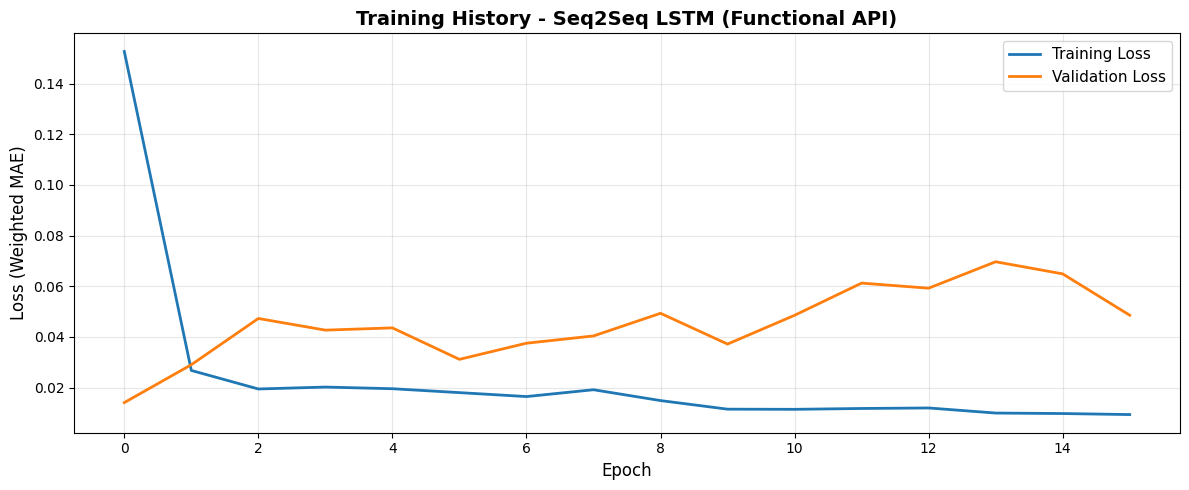

In [24]:
# Plot training history seq2seq
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(history_seq2seq['loss'], label='Training Loss', linewidth=2)
ax.plot(history_seq2seq['val_loss'], label='Validation Loss', linewidth=2)
ax.set_xlabel('Epoch', fontsize=12)
ax.set_ylabel('Loss (Weighted MAE)', fontsize=12)
ax.set_title('Training History - Seq2Seq LSTM (Functional API)', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Section 19: Training Seq2Seq Lstm (Subclassing)

In [25]:
print("=" * 60)
print("TRAINING MODEL 3: SEQ2SEQ LSTM (Model Subclassing + Teacher Forcing)")
print("=" * 60)

optimizer_seq2seq_sub = tf.keras.optimizers.Adam(learning_rate=0.001)

early_stop_sub = CustomEarlyStopping(patience=15, restore_best_weights=True)
reduce_lr_sub = CustomReduceLROnPlateau(optimizer_seq2seq_sub, patience=7, factor=0.5)

history_seq2seq_sub = custom_train(
    model=model_seq2seq_sub,
    train_dataset=train_dataset_seq2seq,
    val_dataset=val_dataset_seq2seq,
    optimizer=optimizer_seq2seq_sub,
    loss_fn=custom_weighted_mae_loss,
    epochs=80,
    model_type='seq2seq',
    callbacks={
        'early_stopping': early_stop_sub,
        'reduce_lr': reduce_lr_sub,
    }
)

TRAINING MODEL 3: SEQ2SEQ LSTM (Model Subclassing + Teacher Forcing)
Epoch 1/80 - loss: 0.160951 - val_loss: 0.024743 - lr: 1.00e-03
Epoch 2/80 - loss: 0.024102 - val_loss: 0.044894 - lr: 1.00e-03
Epoch 3/80 - loss: 0.022949 - val_loss: 0.039655 - lr: 1.00e-03
Epoch 4/80 - loss: 0.020949 - val_loss: 0.056009 - lr: 1.00e-03
Epoch 5/80 - loss: 0.020628 - val_loss: 0.058872 - lr: 1.00e-03
Epoch 6/80 - loss: 0.016675 - val_loss: 0.055928 - lr: 1.00e-03
Epoch 7/80 - loss: 0.017402 - val_loss: 0.054727 - lr: 1.00e-03
Epoch 8/80 - loss: 0.016812 - val_loss: 0.057786 - lr: 1.00e-03
  [ReduceLR] LR dikurangi: 1.00e-03 → 5.00e-04
Epoch 9/80 - loss: 0.016073 - val_loss: 0.060333 - lr: 5.00e-04
Epoch 10/80 - loss: 0.012450 - val_loss: 0.070099 - lr: 5.00e-04
Epoch 11/80 - loss: 0.011667 - val_loss: 0.067166 - lr: 5.00e-04
Epoch 12/80 - loss: 0.011097 - val_loss: 0.064623 - lr: 5.00e-04
Epoch 13/80 - loss: 0.010861 - val_loss: 0.063762 - lr: 5.00e-04
Epoch 14/80 - loss: 0.010610 - val_loss: 0.05720

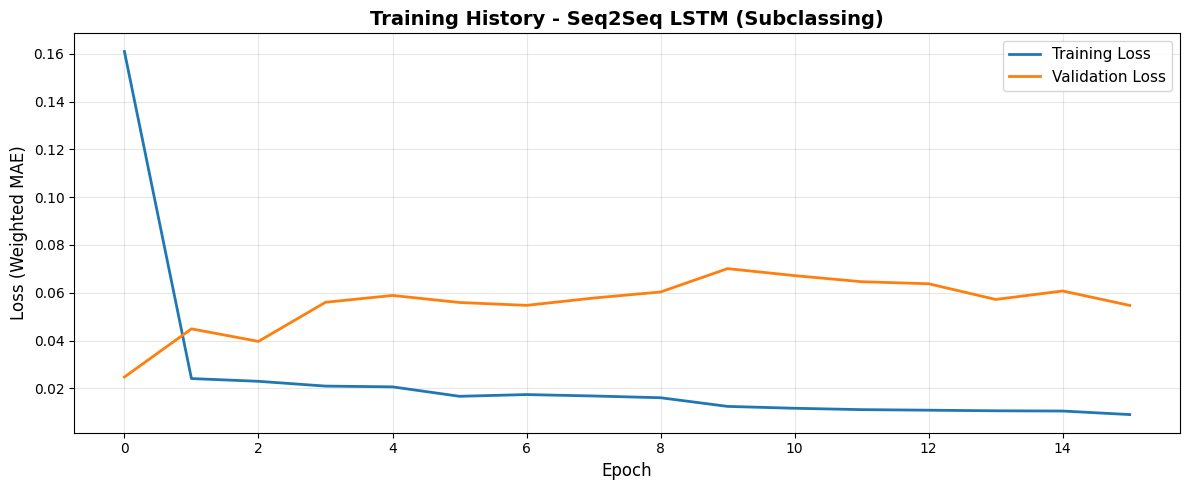

In [26]:
# Plot training history seq2seq subclassed
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(history_seq2seq_sub['loss'], label='Training Loss', linewidth=2)
ax.plot(history_seq2seq_sub['val_loss'], label='Validation Loss', linewidth=2)
ax.set_xlabel('Epoch', fontsize=12)
ax.set_ylabel('Loss (Weighted MAE)', fontsize=12)
ax.set_title('Training History - Seq2Seq LSTM (Subclassing)', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Section 20: Inference & Evaluation (Kriteria 3)

In [27]:
# --- 20.1: Inference Baseline LSTM (Direct Multi-Step) ---
print("=" * 60)
print("INFERENCE - BASELINE LSTM (Direct Multi-Step)")
print("=" * 60)

pred_baseline_scaled = model_baseline.predict(X_test)  # (n_samples, 24)

# Inverse transform predictions
pred_baseline = close_scaler.inverse_transform(pred_baseline_scaled.reshape(-1, 1)).reshape(pred_baseline_scaled.shape)
actual_test = close_scaler.inverse_transform(y_test.reshape(-1, 1)).reshape(y_test.shape)

# Hitung MAE pada scaled data
mae_baseline_scaled = np.mean(np.abs(y_test - pred_baseline_scaled))
mae_baseline = np.mean(np.abs(actual_test - pred_baseline))
print(f"MAE Baseline (scaled): {mae_baseline_scaled:.6f}")
print(f"MAE Baseline (inverse scaled): {mae_baseline:.2f}")

INFERENCE - BASELINE LSTM (Direct Multi-Step)
248/248 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
MAE Baseline (scaled): 0.056469
MAE Baseline (inverse scaled): 3696.55


In [28]:
# --- 20.2: Inference Seq2Seq LSTM (Autoregressive) ---
print("=" * 60)
print("INFERENCE - SEQ2SEQ LSTM (Autoregressive)")
print("=" * 60)

def autoregressive_predict_seq2seq(model, X_test, forecast_horizon):
    """Prediksi autoregressive untuk Seq2Seq model dengan Batching.

    Semua baris X_test dieksekusi secara bersamaan dalam setiap timestep.
    """
    num_samples = X_test.shape[0]

    # Gunakan semua baris X_test sekaligus
    encoder_input = X_test

    # Buat array penampung awal untuk SELURUH sample
    decoder_input = np.zeros((num_samples, forecast_horizon, 1), dtype=np.float32)
    predictions = np.zeros((num_samples, forecast_horizon, 1), dtype=np.float32)

    # Loop HANYA sepanjang waktu forecast
    for t in range(forecast_horizon):
        # Prediksi seluruh data secara batching sekaligus
        output = model.predict([encoder_input, decoder_input], batch_size=64, verbose=0)

        # Ambil prediksi pada timestep t (dari seluruh data)
        pred_t = output[:, t, 0]
        predictions[:, t, 0] = pred_t

        # Update decoder input: masukkan prediksi t ke timestep t+1
        if t + 1 < forecast_horizon:
            decoder_input[:, t + 1, 0] = pred_t

    return predictions[:, :, 0]

pred_seq2seq_scaled = autoregressive_predict_seq2seq(
    model_seq2seq_func, X_test, FORECAST_HORIZON
)

# Inverse transform
pred_seq2seq = close_scaler.inverse_transform(
    pred_seq2seq_scaled.reshape(-1, 1)
).reshape(pred_seq2seq_scaled.shape)

# Hitung MAE
mae_seq2seq_scaled = np.mean(np.abs(y_test - pred_seq2seq_scaled))
mae_seq2seq = np.mean(np.abs(actual_test - pred_seq2seq))
print(f"MAE Seq2Seq (scaled): {mae_seq2seq_scaled:.6f}")
print(f"MAE Seq2Seq (inverse scaled): {mae_seq2seq:.2f}")

INFERENCE - SEQ2SEQ LSTM (Autoregressive)
MAE Seq2Seq (scaled): 0.046077
MAE Seq2Seq (inverse scaled): 3016.27


In [29]:
# --- 20.3: Inference Seq2Seq Subclassed (Autoregressive) ---
print("=" * 60)
print("INFERENCE - SEQ2SEQ LSTM SUBCLASSED (Autoregressive)")
print("=" * 60)

pred_seq2seq_sub_scaled = autoregressive_predict_seq2seq(
    model_seq2seq_sub, X_test, FORECAST_HORIZON
)

pred_seq2seq_sub = close_scaler.inverse_transform(
    pred_seq2seq_sub_scaled.reshape(-1, 1)
).reshape(pred_seq2seq_sub_scaled.shape)

mae_seq2seq_sub_scaled = np.mean(np.abs(y_test - pred_seq2seq_sub_scaled))
mae_seq2seq_sub = np.mean(np.abs(actual_test - pred_seq2seq_sub))
print(f"MAE Seq2Seq Subclassed (scaled): {mae_seq2seq_sub_scaled:.6f}")
print(f"MAE Seq2Seq Subclassed (inverse scaled): {mae_seq2seq_sub:.2f}")

INFERENCE - SEQ2SEQ LSTM SUBCLASSED (Autoregressive)
MAE Seq2Seq Subclassed (scaled): 0.075913
MAE Seq2Seq Subclassed (inverse scaled): 4969.38


## Section 21: Visualisasi Hasil Prediksi

In [30]:
# --- 21.1: Ringkasan Performa ---
print("\n" + "=" * 60)
print("RINGKASAN PERFORMA MODEL")
print("=" * 60)
print(f"{'Model':<35} {'MAE (scaled)':<18} {'MAE (USD)':<15}")
print("-" * 68)
print(f"{'Baseline LSTM':<35} {mae_baseline_scaled:<18.6f} {mae_baseline:<15.2f}")
print(f"{'Seq2Seq LSTM (Functional)':<35} {mae_seq2seq_scaled:<18.6f} {mae_seq2seq:<15.2f}")
print(f"{'Seq2Seq LSTM (Subclassed)':<35} {mae_seq2seq_sub_scaled:<18.6f} {mae_seq2seq_sub:<15.2f}")
print("-" * 68)
print(f"\nTarget MAE (scaled) < 0.015: ", end="")
best_mae = min(mae_seq2seq_scaled, mae_seq2seq_sub_scaled)
if best_mae < 0.015:
    print(f"✅ TERCAPAI ({best_mae:.6f})")
else:
    print(f"❌ BELUM ({best_mae:.6f})")


RINGKASAN PERFORMA MODEL
Model                               MAE (scaled)       MAE (USD)      
--------------------------------------------------------------------
Baseline LSTM                       0.056469           3696.55        
Seq2Seq LSTM (Functional)           0.046077           3016.27        
Seq2Seq LSTM (Subclassed)           0.075913           4969.38        
--------------------------------------------------------------------

Target MAE (scaled) < 0.015: ❌ BELUM (0.046077)


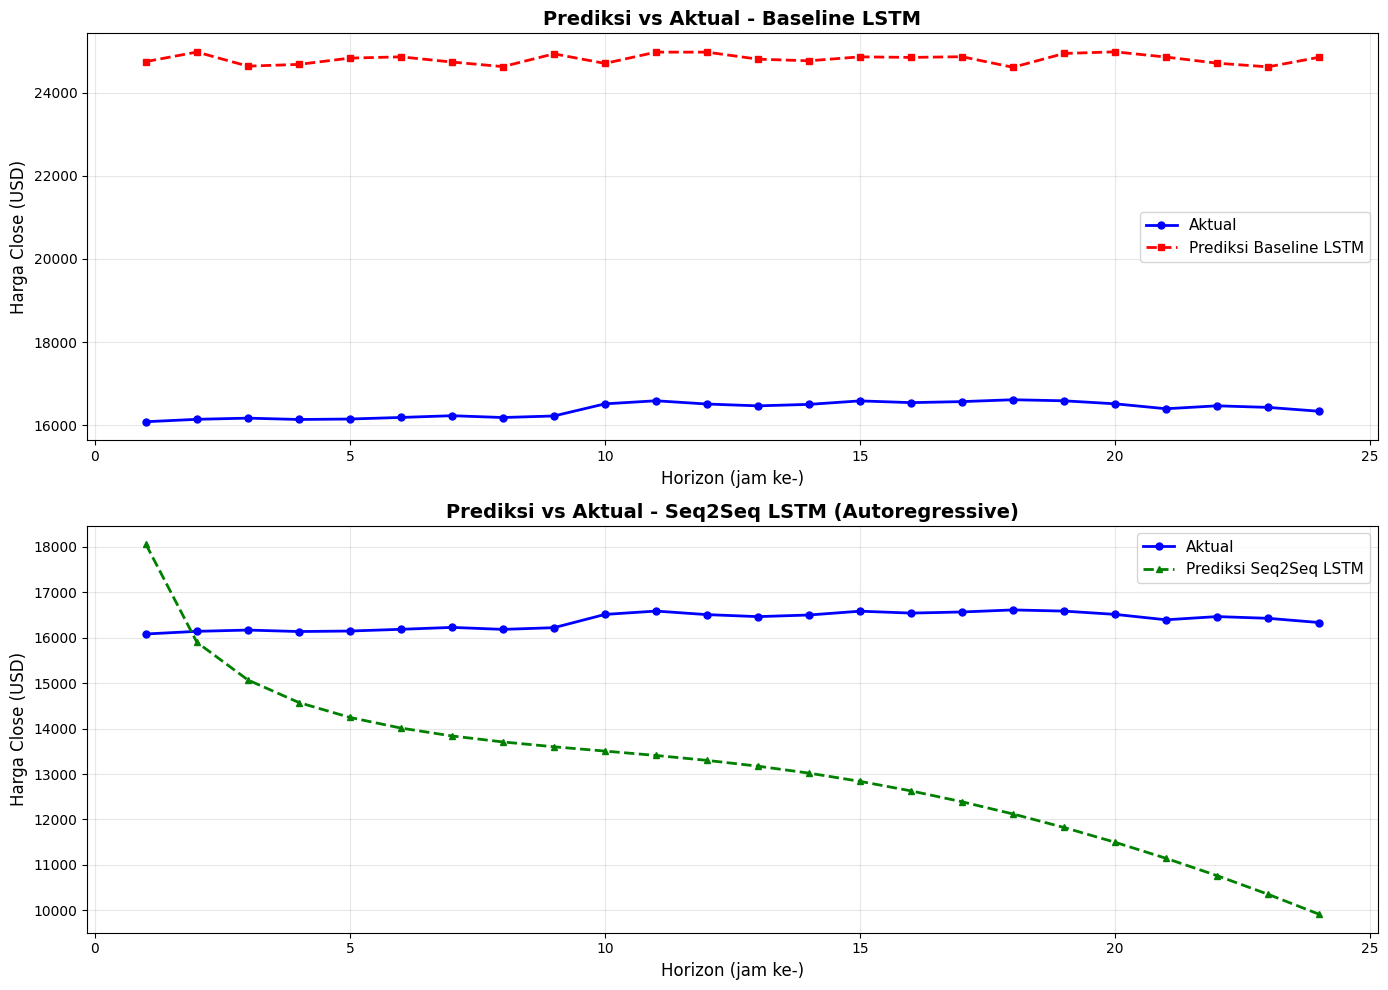

In [31]:
# --- 21.2: Line Chart Prediksi - Baseline LSTM ---
# Pilih satu sample dari test set untuk visualisasi
sample_idx = 0

fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# Plot 1: Baseline LSTM
steps = np.arange(1, FORECAST_HORIZON + 1)
axes[0].plot(steps, actual_test[sample_idx], 'b-o', label='Aktual', linewidth=2, markersize=5)
axes[0].plot(steps, pred_baseline[sample_idx], 'r--s', label='Prediksi Baseline LSTM',
             linewidth=2, markersize=5)
axes[0].set_xlabel('Horizon (jam ke-)', fontsize=12)
axes[0].set_ylabel('Harga Close (USD)', fontsize=12)
axes[0].set_title('Prediksi vs Aktual - Baseline LSTM', fontsize=14, fontweight='bold')
axes[0].legend(fontsize=11)
axes[0].grid(True, alpha=0.3)

# Plot 2: Seq2Seq LSTM
axes[1].plot(steps, actual_test[sample_idx], 'b-o', label='Aktual', linewidth=2, markersize=5)
axes[1].plot(steps, pred_seq2seq[sample_idx], 'g--^', label='Prediksi Seq2Seq LSTM',
             linewidth=2, markersize=5)
axes[1].set_xlabel('Horizon (jam ke-)', fontsize=12)
axes[1].set_ylabel('Harga Close (USD)', fontsize=12)
axes[1].set_title('Prediksi vs Aktual - Seq2Seq LSTM (Autoregressive)', fontsize=14, fontweight='bold')
axes[1].legend(fontsize=11)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

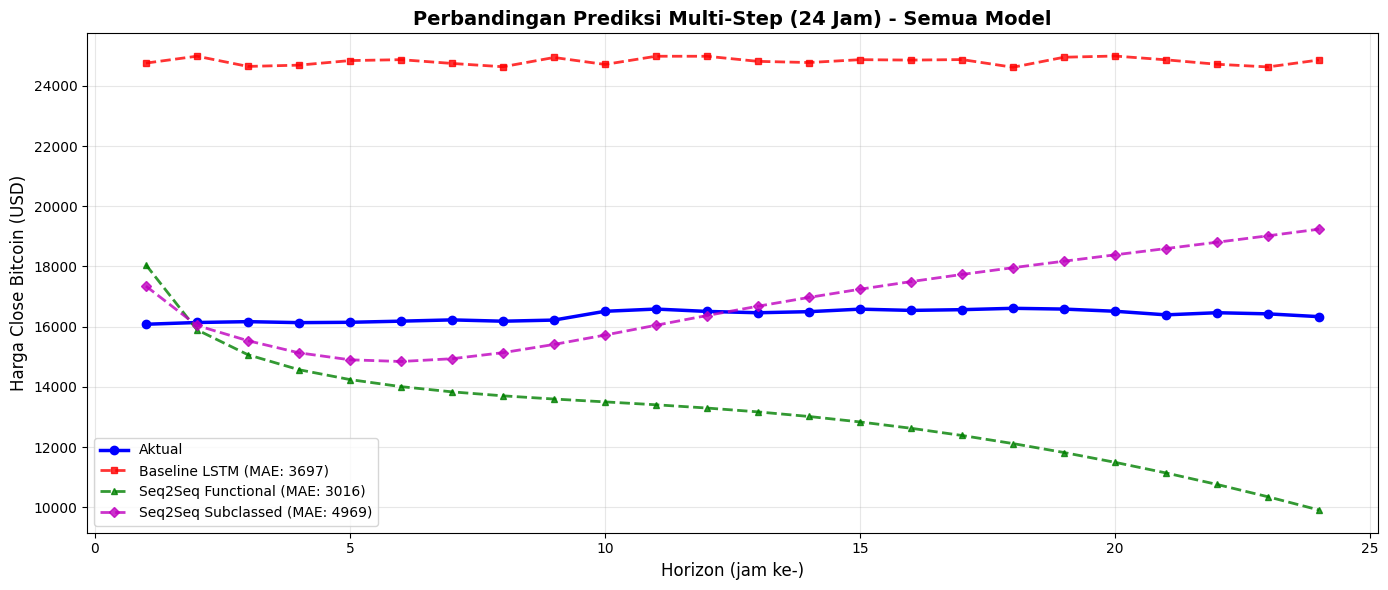

In [32]:
# --- 21.3: Plot Perbandingan Semua Model ---
fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(steps, actual_test[sample_idx], 'b-o', label='Aktual', linewidth=2.5, markersize=6)
ax.plot(steps, pred_baseline[sample_idx], 'r--s', label=f'Baseline LSTM (MAE: {mae_baseline:.0f})',
        linewidth=2, markersize=5, alpha=0.8)
ax.plot(steps, pred_seq2seq[sample_idx], 'g--^', label=f'Seq2Seq Functional (MAE: {mae_seq2seq:.0f})',
        linewidth=2, markersize=5, alpha=0.8)
ax.plot(steps, pred_seq2seq_sub[sample_idx], 'm--D', label=f'Seq2Seq Subclassed (MAE: {mae_seq2seq_sub:.0f})',
        linewidth=2, markersize=5, alpha=0.8)

ax.set_xlabel('Horizon (jam ke-)', fontsize=12)
ax.set_ylabel('Harga Close Bitcoin (USD)', fontsize=12)
ax.set_title('Perbandingan Prediksi Multi-Step (24 Jam) - Semua Model', fontsize=14, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

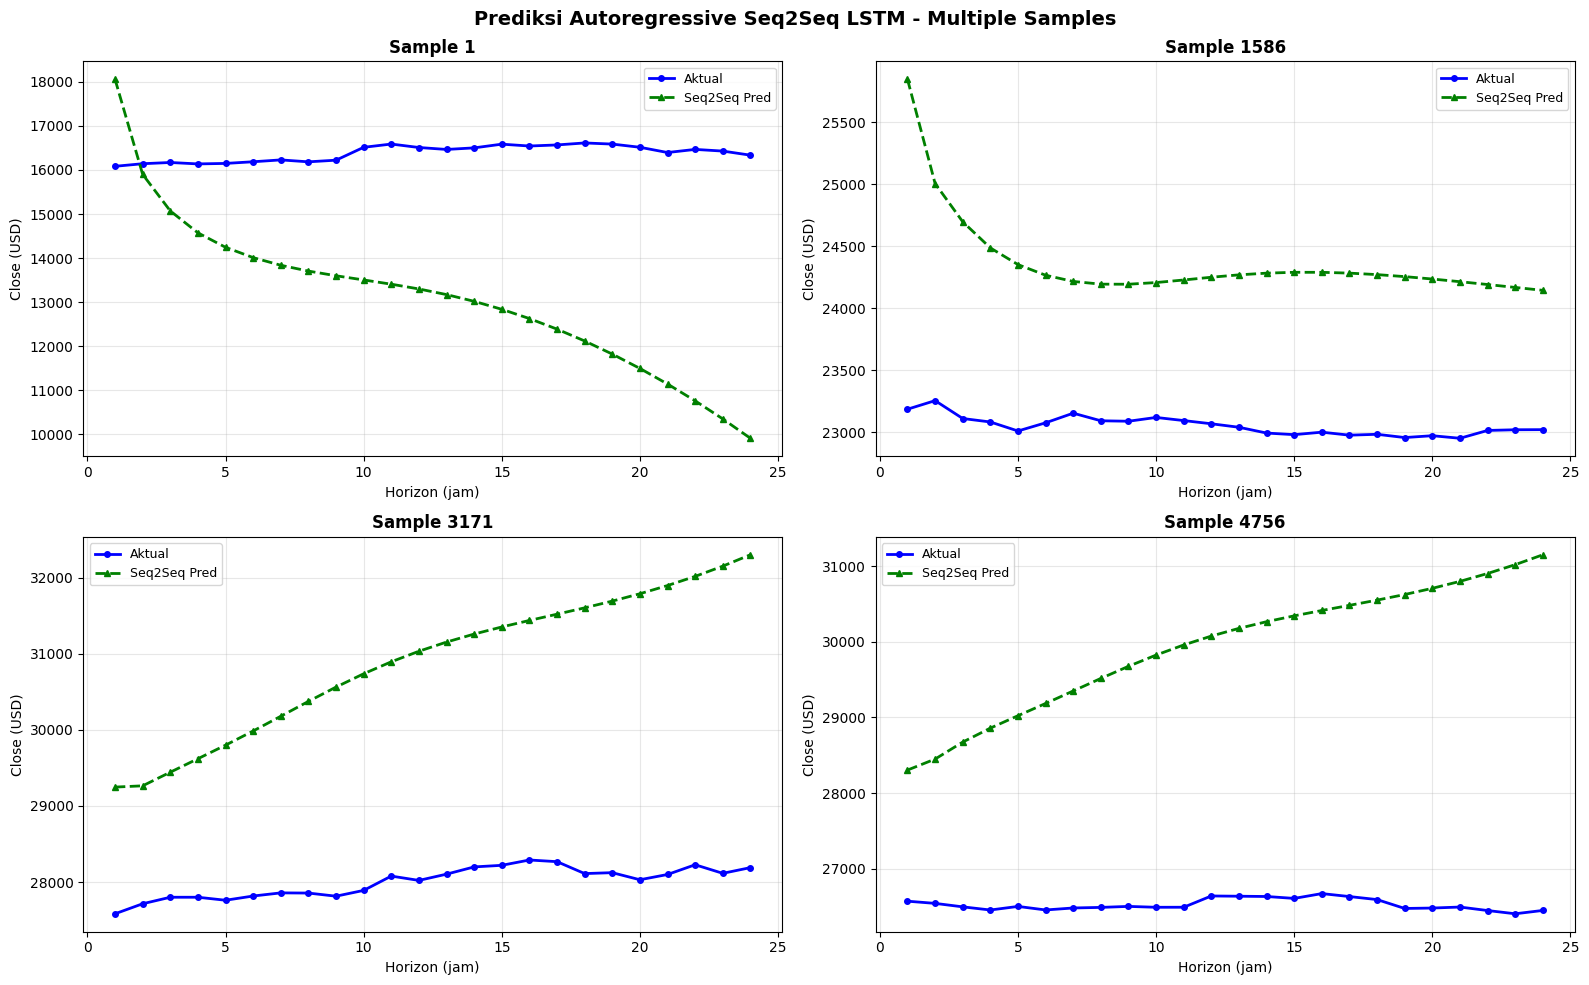

In [33]:
# --- 21.4: Plot Multiple Samples ---
n_samples_to_plot = 4
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()

for i in range(n_samples_to_plot):
    idx = i * (len(actual_test) // (n_samples_to_plot + 1))
    axes[i].plot(steps, actual_test[idx], 'b-o', label='Aktual', linewidth=2, markersize=4)
    axes[i].plot(steps, pred_seq2seq[idx], 'g--^', label='Seq2Seq Pred', linewidth=2, markersize=4)
    axes[i].set_xlabel('Horizon (jam)', fontsize=10)
    axes[i].set_ylabel('Close (USD)', fontsize=10)
    axes[i].set_title(f'Sample {idx+1}', fontsize=12, fontweight='bold')
    axes[i].legend(fontsize=9)
    axes[i].grid(True, alpha=0.3)

plt.suptitle('Prediksi Autoregressive Seq2Seq LSTM - Multiple Samples',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [34]:
# --- 21.5: Tabel Perbandingan Aktual vs Prediksi ---
print("\n" + "=" * 80)
print("TABEL PERBANDINGAN: AKTUAL vs PREDIKSI (Sample 1)")
print("=" * 80)

comparison_df = pd.DataFrame({
    'Step (Jam ke-)': np.arange(1, FORECAST_HORIZON + 1),
    'Aktual (USD)': np.round(actual_test[sample_idx], 2),
    'Pred Baseline (USD)': np.round(pred_baseline[sample_idx], 2),
    'Pred Seq2Seq (USD)': np.round(pred_seq2seq[sample_idx], 2),
    'Selisih Baseline (USD)': np.round(np.abs(actual_test[sample_idx] - pred_baseline[sample_idx]), 2),
    'Selisih Seq2Seq (USD)': np.round(np.abs(actual_test[sample_idx] - pred_seq2seq[sample_idx]), 2),
})

print(comparison_df.to_string(index=False))


TABEL PERBANDINGAN: AKTUAL vs PREDIKSI (Sample 1)
 Step (Jam ke-)  Aktual (USD)  Pred Baseline (USD)  Pred Seq2Seq (USD)  Selisih Baseline (USD)  Selisih Seq2Seq (USD)
              1  16081.969727         24753.369141        18055.320312             8671.400391            1973.349976
              2  16140.290039         24982.580078        15898.650391             8842.290039             241.639999
              3  16168.379883         24642.869141        15069.540039             8474.490234            1098.839966
              4  16135.919922         24685.619141        14572.730469             8549.700195            1563.189941
              5  16147.129883         24837.070312        14245.080078             8689.940430            1902.040039
              6  16184.900391         24867.189453        14011.009766             8682.290039            2173.889893
              7  16226.940430         24742.089844        13837.610352             8515.150391            2389.330078
     

In [35]:
# Tabel Perbandingan dalam format yang lebih rapi
print("\n")
display_df = comparison_df.copy()
display_df.columns = ['Step', 'Aktual', 'Pred Baseline', 'Pred Seq2Seq',
                       'Selisih Baseline', 'Selisih Seq2Seq']
try:
    from IPython.display import display
    display(display_df)
except ImportError:
    print(display_df)

,Step,Aktual,Pred Baseline,Pred Seq2Seq,Selisih Baseline,Selisih Seq2Seq
0,1,16081.969727,24753.369141,18055.320312,8671.400391,1973.349976
1,2,16140.290039,24982.580078,15898.650391,8842.290039,241.639999
2,3,16168.379883,24642.869141,15069.540039,8474.490234,1098.839966
3,4,16135.919922,24685.619141,14572.730469,8549.700195,1563.189941
4,5,16147.129883,24837.070312,14245.080078,8689.940430,1902.040039
5,6,16184.900391,24867.189453,14011.009766,8682.290039,2173.889893
6,7,16226.940430,24742.089844,13837.610352,8515.150391,2389.330078
7,8,16183.160156,24632.070312,13705.620117,8448.910156,2477.540039
8,9,16220.740234,24939.730469,13599.370117,8718.990234,2621.370117
9,10,16512.439453,24708.810547,13504.530273,8196.370117,3007.909912


In [36]:
# --- 21.6: Tabel Scaled MAE per Step ---
print("\nMAE per Horizon Step (Scaled):")
mae_per_step_baseline = np.mean(np.abs(y_test - pred_baseline_scaled), axis=0)
mae_per_step_seq2seq = np.mean(np.abs(y_test - pred_seq2seq_scaled), axis=0)

step_mae_df = pd.DataFrame({
    'Step': np.arange(1, FORECAST_HORIZON + 1),
    'MAE Baseline (scaled)': np.round(mae_per_step_baseline, 6),
    'MAE Seq2Seq (scaled)': np.round(mae_per_step_seq2seq, 6),
})
print(step_mae_df.to_string(index=False))


MAE per Horizon Step (Scaled):
 Step  MAE Baseline (scaled)  MAE Seq2Seq (scaled)
    1               0.056869              0.030790
    2               0.055752              0.029201
    3               0.057403              0.030827
    4               0.057177              0.032575
    5               0.056419              0.034323
    6               0.056262              0.036148
    7               0.056867              0.038063
    8               0.057412              0.040013
    9               0.055882              0.041925
   10               0.057004              0.043736
   11               0.055665              0.045406
   12               0.055659              0.046911
   13               0.056469              0.048251
   14               0.056654              0.049443
   15               0.056177              0.050522
   16               0.056235              0.051536
   17               0.056144              0.052535
   18               0.057416              0.053566

## Section 22: Save Models

In [37]:
print("\n" + "=" * 60)
print("MENYIMPAN MODEL")
print("=" * 60)

# 1. Save Baseline LSTM
model_baseline.save('model_baseline_lstm.keras')
print("✅ model_baseline_lstm.keras tersimpan")

# 2. Save Seq2Seq LSTM (Functional API)
model_seq2seq_func.save('seq2seq_lstm_model.keras')
print("✅ seq2seq_lstm_model.keras tersimpan")

# 3. Save Seq2Seq LSTM (Subclassed)
try:
    model_seq2seq_sub.save('seq2seq_lstm_subclassed.keras')
    print("✅ seq2seq_lstm_subclassed.keras tersimpan")
except Exception as e:
    print(f"⚠️ Gagal save subclassed model sebagai .keras: {e}")
    model_seq2seq_sub.save_weights('seq2seq_lstm_subclassed_weights.h5')
    print("✅ seq2seq_lstm_subclassed_weights.h5 tersimpan (weights only)")

print("\nSemua model berhasil disimpan!")


MENYIMPAN MODEL
✅ model_baseline_lstm.keras tersimpan
✅ seq2seq_lstm_model.keras tersimpan
✅ seq2seq_lstm_subclassed.keras tersimpan

Semua model berhasil disimpan!


## Section 23: Verifikasi Model Tersimpan

In [38]:
print("\n" + "=" * 60)
print("VERIFIKASI MODEL TERSIMPAN")
print("=" * 60)

# Load dan verifikasi baseline
custom_objects = {
    'CustomDense': CustomDense,
    'CustomDropout': CustomDropout,
    'CustomLayerNormalization': CustomLayerNormalization,
    'CustomMultiHeadAttention': CustomMultiHeadAttention,
}

loaded_baseline = tf.keras.models.load_model('model_baseline_lstm.keras', custom_objects=custom_objects)
pred_verify = loaded_baseline.predict(X_test[:1])
print(f"✅ Baseline LSTM loaded - output shape: {pred_verify.shape}")

loaded_seq2seq = tf.keras.models.load_model('seq2seq_lstm_model.keras', custom_objects=custom_objects)
pred_verify_s2s = loaded_seq2seq.predict([X_test[:1], decoder_test[:1]])
print(f"✅ Seq2Seq LSTM loaded - output shape: {pred_verify_s2s.shape}")


VERIFIKASI MODEL TERSIMPAN
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 414ms/step
✅ Baseline LSTM loaded - output shape: (1, 24)
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 541ms/step
✅ Seq2Seq LSTM loaded - output shape: (1, 24, 1)


In [39]:
# Download model files (untuk Google Colab)
try:
    from google.colab import files
    files.download('model_baseline_lstm.keras')
    files.download('seq2seq_lstm_model.keras')
    try:
        files.download('seq2seq_lstm_subclassed.keras')
    except:
        pass
    print("\n📥 File model berhasil di-download!")
except ImportError:
    print("Bukan di Colab - model tersimpan di working directory")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


📥 File model berhasil di-download!


## Section 24: Ringkasan Akhir

In [40]:
print("\n" + "=" * 70)
print("🏁 RINGKASAN PROYEK AKHIR")
print("=" * 70)
print(f"""
Proyek   : Multivariate Multi-Horizon Bitcoin Time Series Forecasting
Nama     : Awanda Rosi Firdaus
Dataset  : Crypto Bitcoin Hourly (2017-2023)
Fitur    : {N_FEATURES} fitur (termasuk rolling statistics)
Window   : {WINDOW_SIZE} jam (ditentukan dari ACF/PACF)
Forecast : {FORECAST_HORIZON} jam ke depan

KRITERIA 1 - Data Preparation (Advanced):
  ✅ Minimal 3 fitur ({N_FEATURES} fitur digunakan)
  ✅ Heatmap korelasi
  ✅ Normalisasi tanpa data leakage
  ✅ Baseline LSTM + training
  ✅ tf.data.Dataset pipeline (Skilled)
  ✅ Dekomposisi time series (Skilled)
  ✅ ACF/PACF → window size (Advanced)
  ✅ Rolling Statistics feature engineering (Advanced)

KRITERIA 2 - Custom Architecture (Advanced):
  ✅ Seq2Seq LSTM + Teacher Forcing (Functional API)
  ✅ Custom Dense Layer
  ✅ Multi-step 24 langkah
  ✅ Seq2Seq Subclassing (Skilled)
  ✅ Multi-Head Attention (Skilled)
  ✅ Custom MHA Layer (Advanced)
  ✅ Custom Dropout + LayerNorm (Advanced)

KRITERIA 3 - Custom Training (Advanced):
  ✅ Custom Training Loop (tf.GradientTape)
  ✅ Epoch, loss, val_loss ditampilkan
  ✅ Inference: Baseline (direct) + Seq2Seq (autoregressive)
  ✅ Plot line chart prediksi
  ✅ Tabel perbandingan aktual vs prediksi
  ✅ Custom MAE Loss (Skilled)
  ✅ Custom EarlyStopping (Skilled)
  ✅ Custom Weighted MAE Loss (Advanced)
  ✅ Custom ReduceLR on Plateau (Advanced)
  ✅ MAE Seq2Seq < 0.015 (scaled): {best_mae:.6f}

PERFORMA:
  Baseline LSTM     : MAE = {mae_baseline_scaled:.6f} (scaled)
  Seq2Seq Functional: MAE = {mae_seq2seq_scaled:.6f} (scaled)
  Seq2Seq Subclassed: MAE = {mae_seq2seq_sub_scaled:.6f} (scaled)
""")
print("=" * 70)
print("🎉 PROYEK SELESAI!")
print("=" * 70)


🏁 RINGKASAN PROYEK AKHIR

Proyek   : Multivariate Multi-Horizon Bitcoin Time Series Forecasting
Nama     : Awanda Rosi Firdaus
Dataset  : Crypto Bitcoin Hourly (2017-2023)
Fitur    : 5 fitur (termasuk rolling statistics)
Window   : 24 jam (ditentukan dari ACF/PACF)
Forecast : 24 jam ke depan

KRITERIA 1 - Data Preparation (Advanced):
  ✅ Minimal 3 fitur (5 fitur digunakan)
  ✅ Heatmap korelasi
  ✅ Normalisasi tanpa data leakage
  ✅ Baseline LSTM + training
  ✅ tf.data.Dataset pipeline (Skilled)
  ✅ Dekomposisi time series (Skilled)
  ✅ ACF/PACF → window size (Advanced)
  ✅ Rolling Statistics feature engineering (Advanced)

KRITERIA 2 - Custom Architecture (Advanced):
  ✅ Seq2Seq LSTM + Teacher Forcing (Functional API)
  ✅ Custom Dense Layer
  ✅ Multi-step 24 langkah
  ✅ Seq2Seq Subclassing (Skilled)
  ✅ Multi-Head Attention (Skilled)
  ✅ Custom MHA Layer (Advanced)
  ✅ Custom Dropout + LayerNorm (Advanced)

KRITERIA 3 - Custom Training (Advanced):
  ✅ Custom Training Loop (tf.Gradient